# 1987 Black Monday — Buy-the-Dip Futures Backtest

A quantitative analysis of the *"buy when price drops 5%"* rule applied to S&P 500 futures during the 1987 Black Monday crash.

This notebook consolidates `data_loader.py`, `backtest.py`, `visualizer.py`, and `main.py` into a single end-to-end pipeline for submission.

## 1. Imports & Configuration

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import os

# ── Robust project-root detection ───────────────────────────────────────────
# Works regardless of whether the kernel was launched from the project root,
# src/, a parent directory, or via VS Code.
try:
    # VS Code sets this magic variable to the notebook's absolute path
    _root = Path(globals()["__vsc_ipynb_file__"]).parent
except KeyError:
    _root = Path(os.path.abspath("")).resolve()
    # Walk up until we find the data directory (max 4 levels)
    for _ in range(4):
        if (_root / "data" / "1987_crash_market_data.csv").exists():
            break
        _root = _root.parent

output_dir = _root / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)
data_path  = _root / "data" / "1987_crash_market_data.csv"

print("Project root :", _root)
print("Data file    :", data_path, " exists =", data_path.exists())
print("Output dir   :", output_dir)

# ── Shared backtest parameters ──────────────────────────────────────────────
COMMON = dict(
    initial_capital   = 100_000,
    dip_threshold     = 0.05,
    position_pct      = 0.25,
    multiplier        = 500,
    initial_margin    = 10_000,
    maintenance_margin= 6_000,
)
BLOWUP_THRESHOLD = 10_000   # cannot open 1 contract
BLOWUP_DRAWDOWN  = 0.95     # 95% loss
MARGIN_DELAYS    = [0, 5, 10, 15, 30, 45]

Project root : d:\Quant Finance\Quant Program\Week 0\Vibe Coding Task
Data file    : d:\Quant Finance\Quant Program\Week 0\Vibe Coding Task\data\1987_crash_market_data.csv  exists = True
Output dir   : d:\Quant Finance\Quant Program\Week 0\Vibe Coding Task\outputs


## 2. Data Loader

Loads and cleans the 1987 crash CSV: removes weekends, trading halts (null futures prices), and non-trading hours (outside 09:30-16:00 EST).

In [2]:
def load_data(filepath):
    """Load and clean 1987 crash market data from CSV."""
    df = pd.read_csv(filepath)
    df['Timestamp']    = pd.to_datetime(df['Timestamp'], format='%m/%d/%Y %H:%M')
    df['SP500_Futures'] = pd.to_numeric(df['SP500_Futures'], errors='coerce')
    # Remove weekends
    df = df[df['Timestamp'].dt.dayofweek < 5].copy()
    # Remove trading halts (null futures values)
    df = df[df['SP500_Futures'].notna()].copy()
    # Keep only trading hours 09:30-16:00
    df = df[df['Timestamp'].dt.hour.isin(range(9, 16))].copy()
    return df.sort_values('Timestamp').reset_index(drop=True)


def get_halt_periods(filepath):
    """Detect trading halt periods from raw data (before filtering)."""
    df = pd.read_csv(filepath)
    df['Timestamp']    = pd.to_datetime(df['Timestamp'], format='%m/%d/%Y %H:%M')
    df['SP500_Futures'] = pd.to_numeric(df['SP500_Futures'], errors='coerce')
    df = df[df['Timestamp'].dt.dayofweek < 5].copy()
    halts, in_halt, halt_start = [], False, None
    for _, row in df.iterrows():
        is_null = pd.isna(row['SP500_Futures'])
        if is_null and not in_halt:
            in_halt, halt_start = True, row['Timestamp']
        elif not is_null and in_halt:
            in_halt = False
            halts.append((halt_start, row['Timestamp']))
    return halts


df           = load_data(str(data_path))
halt_periods = get_halt_periods(str(data_path))
n_days = df['Timestamp'].dt.date.nunique()
print(f'Loaded {len(df)} rows across {n_days} trading days')
df.head()

Loaded 1291 rows across 4 trading days


,Timestamp,DOW_Futures,SP500_Futures,MMI_Futures,Treasury,Nikkei_Futures,Gold_Futures,Oil_Futures
0,1987-10-16 09:00:00,2350.69,298.0,449.14,95.0,25988.04,465.0,20.0
1,1987-10-16 09:01:00,2350.67,298.0,449.13,95.0,25988.04,465.0,20.0
2,1987-10-16 09:02:00,2350.64,298.0,449.13,95.0,25988.04,465.0,20.0
3,1987-10-16 09:03:00,2350.62,298.0,449.12,95.0,25988.04,465.0,20.0
4,1987-10-16 09:04:00,2350.6,298.0,449.12,95.0,25988.04,465.0,20.0


## 3. Backtest Engine

Core event-loop simulator with three entry modes:

| Mode | Description |
|------|-------------|
| `single` | Buy once on first -5% cross per day (disciplined) |
| `step_down` | Buy at each additional -5% step (-5%, -10%, -15%, ...) |
| `per_tick` | Buy every minute while below threshold (most naive) |

Execution model: 1-tick fill delay, configurable slippage and margin-call delay.

In [3]:
def run_backtest(df, initial_capital=100_000, position_pct=0.25, dip_threshold=0.05,
                 margin_call_delay=30, slippage_bps=50,
                 entry_mode='step_down', martingale=False,
                 block_buys_during_mc=True,
                 multiplier=500, initial_margin=10_000, maintenance_margin=6_000,
                 scenario_name='Default'):
    prices_list     = list(df['SP500_Futures'])
    timestamps_list = list(df['Timestamp'])
    n = len(prices_list)

    positions, realized_pnl = [], 0.0
    portfolio_history, buy_events = [], []
    bankruptcy_time = margin_call_time = None
    margin_call_count = max_contracts_held = 0
    max_notional_exposure = 0.0
    peak_equity = initial_capital
    current_date = None
    rolling_daily_high = 0
    liquidated = False
    pending_margin_call = margin_call_trigger_time = None
    single_fired_today = False
    last_step_level = 0
    last_contracts_bought = 0
    pending_buy = None

    for i in range(n):
        timestamp = timestamps_list[i]
        price     = prices_list[i]

        # Execute pending buy (next-minute fill to avoid look-ahead bias)
        if pending_buy is not None and not liquidated:
            slip       = price * (slippage_bps / 10_000)
            fill_price = price + slip
            c          = pending_buy['contracts_to_buy']
            positions.append({'entry_price': fill_price, 'contracts': c})
            buy_events.append({
                'timestamp':    timestamp,
                'price':        fill_price,
                'signal_price': pending_buy['signal_price'],
                'contracts':    c,
                'equity_at_buy':pending_buy['equity_at_signal'],
                'slippage':     slip * c * multiplier
            })
            last_contracts_bought = c
            pending_buy = None

        # Rolling daily high resets each calendar day
        if current_date != timestamp.date():
            current_date = timestamp.date()
            rolling_daily_high = price
            single_fired_today = False
            last_step_level = 0
        rolling_daily_high = max(rolling_daily_high, price)

        # Mark-to-market
        unrealized_pnl    = sum((price - p['entry_price']) * multiplier * p['contracts'] for p in positions)
        equity            = initial_capital + realized_pnl + unrealized_pnl
        total_contracts   = sum(p['contracts'] for p in positions)
        notional_exposure = total_contracts * price * multiplier
        max_contracts_held    = max(max_contracts_held, total_contracts)
        max_notional_exposure = max(max_notional_exposure, notional_exposure)
        peak_equity           = max(peak_equity, equity)

        # Margin call logic
        if total_contracts > 0 and equity < total_contracts * maintenance_margin:
            if margin_call_delay == 0:
                realized_pnl += unrealized_pnl; unrealized_pnl = 0
                equity = initial_capital + realized_pnl
                positions = []; total_contracts = 0
                margin_call_time = margin_call_time or timestamp
                margin_call_count += 1; liquidated = True; pending_buy = None
                if equity <= 0 and bankruptcy_time is None:
                    bankruptcy_time = timestamp
            elif pending_margin_call is None:
                pending_margin_call = timestamp
                margin_call_trigger_time = timestamp

        if pending_margin_call is not None and margin_call_delay > 0:
            elapsed = (timestamp - pending_margin_call).total_seconds() / 60
            if elapsed >= margin_call_delay:
                unrealized_pnl = sum((price - p['entry_price']) * multiplier * p['contracts']
                                     for p in positions)
                realized_pnl += unrealized_pnl; unrealized_pnl = 0
                equity = initial_capital + realized_pnl
                positions = []; total_contracts = 0
                margin_call_time = margin_call_time or margin_call_trigger_time
                margin_call_count += 1; liquidated = True
                pending_margin_call = None; pending_buy = None
                if equity <= 0 and bankruptcy_time is None:
                    bankruptcy_time = timestamp

        if equity <= 0 and bankruptcy_time is None:
            bankruptcy_time = timestamp

        # Buy trigger
        can_buy = (not liquidated and bankruptcy_time is None and equity >= initial_margin)
        if block_buys_during_mc and pending_margin_call is not None:
            can_buy = False
        if liquidated and pending_buy is not None:
            pending_buy = None

        if can_buy and pending_buy is None:
            drop_pct   = (rolling_daily_high - price) / rolling_daily_high if rolling_daily_high > 0 else 0
            should_buy = False
            if entry_mode == 'single':
                if drop_pct >= dip_threshold and not single_fired_today:
                    should_buy = True; single_fired_today = True
            elif entry_mode == 'step_down':
                current_step = int(drop_pct / dip_threshold)
                if current_step > last_step_level and current_step >= 1:
                    should_buy = True; last_step_level = current_step
            elif entry_mode == 'per_tick':
                if drop_pct >= dip_threshold:
                    should_buy = True
            if should_buy:
                if martingale:
                    contracts_to_buy = min(max(1, last_contracts_bought * 2),
                                           max(1, int(equity / initial_margin)))
                else:
                    contracts_to_buy = max(1, int((equity * position_pct) / initial_margin))
                pending_buy = {'contracts_to_buy': contracts_to_buy,
                               'signal_price': price, 'equity_at_signal': equity}

        portfolio_history.append({
            'timestamp': timestamp, 'price': price, 'equity': equity,
            'unrealized_pnl': unrealized_pnl, 'realized_pnl': realized_pnl,
            'total_contracts': total_contracts
        })

    def _stop_loss(ph):
        if not ph: return 0
        ie = ph[0]['equity']
        me = min(p['equity'] for p in ph)
        return 20.0 if (me <= 0 or (1 - me / ie) * 100 >= 90) else 15.0

    return {
        'scenario_name':         scenario_name,
        'portfolio_history':     portfolio_history,
        'buy_events':            buy_events,
        'bankruptcy_time':       bankruptcy_time,
        'margin_call_time':      margin_call_time,
        'margin_call_count':     margin_call_count,
        'final_value':           portfolio_history[-1]['equity'] if portfolio_history else initial_capital,
        'max_contracts_held':    max_contracts_held,
        'max_notional_exposure': max_notional_exposure,
        'peak_equity':           peak_equity,
        'stop_loss_pct':         _stop_loss(portfolio_history),
        'config': {
            'initial_capital': initial_capital, 'position_pct': position_pct,
            'dip_threshold': dip_threshold, 'margin_call_delay': margin_call_delay,
            'slippage_bps': slippage_bps, 'entry_mode': entry_mode,
            'martingale': martingale, 'block_buys_during_mc': block_buys_during_mc,
            'multiplier': multiplier, 'initial_margin': initial_margin,
            'maintenance_margin': maintenance_margin,
        }
    }

print('Backtest engine ready.')

Backtest engine ready.


## 4. Run Scenarios

| Scenario | Entry mode | MC delay | Buy-block during MC |
|----------|-----------|---------|---------------------|
| **Primary** (naive) | step_down | 30 min | No |
| **Control** (disciplined) | single | 30 min | Yes |
| **Sensitivity sweep** | step_down | 0-45 min | No |
| **Per-tick** (worst case) | per_tick | 30 min | No |

In [4]:
def is_blown_up(result):
    cfg = result['config']
    final = result['final_value']
    if result['bankruptcy_time']:                          return True
    if final < BLOWUP_THRESHOLD:                          return True
    if (cfg['initial_capital'] - final) / cfg['initial_capital'] >= BLOWUP_DRAWDOWN: return True
    return False


def fmt_status(r):
    if r['bankruptcy_time'] and r['final_value'] <= 0:
        return 'BANKRUPT (equity <= $0)'
    if r['bankruptcy_time'] and r['final_value'] > 0:
        return f"BANKRUPT (hit $0 intraday, settled ${r['final_value']:,.0f})"
    if is_blown_up(r):
        return 'BLOWN UP (equity < $10K)'
    return 'survived'


# PRIMARY — naive bot
primary = run_backtest(
    df, entry_mode='step_down', margin_call_delay=30, slippage_bps=50,
    block_buys_during_mc=False, scenario_name='Naive bot (step-down)', **COMMON)

# CONTROL — disciplined single-fire
control = run_backtest(
    df, entry_mode='single', margin_call_delay=30, slippage_bps=50,
    block_buys_during_mc=True, scenario_name='Control (single-fire)', **COMMON)

# SENSITIVITY — delay sweep
delay_results = []
for delay in MARGIN_DELAYS:
    r = run_backtest(
        df, entry_mode='step_down', margin_call_delay=delay, slippage_bps=50,
        block_buys_during_mc=False, scenario_name=f'Naive {delay}min delay', **COMMON)
    delay_results.append(r)

# PER-TICK — worst case
per_tick = run_backtest(
    df, entry_mode='per_tick', margin_call_delay=30, slippage_bps=50,
    block_buys_during_mc=False, scenario_name='Naive per-tick', **COMMON)

ic = COMMON['initial_capital']
for label, r in [('PRIMARY  (naive)', primary),
                  ('CONTROL  (single)', control),
                  ('PER-TICK (worst) ', per_tick)]:
    f = r['final_value']
    pct = (f - ic) / ic * 100
    print(f'{label}: ${f:>10,.0f}  ({pct:+.1f}%)  [{fmt_status(r)}]')

PRIMARY  (naive): $    -2,002  (-102.0%)  [BANKRUPT (equity <= $0)]
CONTROL  (single): $   108,583  (+8.6%)  [survived]
PER-TICK (worst) : $   -10,705  (-110.7%)  [BANKRUPT (equity <= $0)]


## 5. Visualisation Functions

In [5]:
def _halt_nan(prices_in, timestamps, halt_periods):
    """Insert NaN at halt boundaries so the price line breaks cleanly."""
    if not halt_periods:
        return list(prices_in)
    pp = list(prices_in)
    for hs, he in halt_periods:
        bi = ai = None
        for i, ts in enumerate(timestamps):
            if ts < hs: bi = i
            if ai is None and ts > he: ai = i
        if bi is not None and ai is not None:
            dur = (he - hs).total_seconds() / 60
            m   = int(dur / 2)
            for j in range(max(0, bi - m), min(len(pp) - 1, ai + m) + 1):
                pp[j] = float('nan')
    return pp


def _halt_bands(axes, timestamps, halt_periods, prices):
    """Draw yellow shaded bands and HALT labels for each trading halt."""
    if not halt_periods:
        return
    for hs, he in halt_periods:
        bi = ai = None
        for i, ts in enumerate(timestamps):
            if ts < hs: bi = i
            if ai is None and ts > he: ai = i
        if bi is None or ai is None:
            continue
        dur = (he - hs).total_seconds() / 60
        m   = int(dur / 2)
        for ax in axes:
            ax.axvspan(bi + 0.5 - m, ai - 0.5 + m,
                       color='#ffeb99', alpha=0.5, zorder=0,
                       edgecolor='#ffd700', linewidth=2)
        axes[-1].text((bi + ai) / 2, max(prices) * 0.92,
                      f'HALT\n{int(dur)}m',
                      fontsize=9, color='#b8860b', ha='center', fontweight='bold',
                      bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                                alpha=0.8, edgecolor='#ffd700'))


def _day_ticks(ax, timestamps):
    dates, starts, cur = [], [], None
    for i, ts in enumerate(timestamps):
        if ts.date() != cur:
            cur = ts.date(); dates.append(cur); starts.append(i)
    ax.set_xticks(starts)
    ax.set_xticklabels([f"{d.strftime('%a').capitalize()}\n{d.strftime('%b %d')}" for d in dates])


def generate_chart(portfolio_history, buy_events, bankruptcy_time, output_path,
                   halt_periods=None, margin_call_time=None):
    """Two-panel chart: account equity (top) + S&P 500 price (bottom)."""
    fig, (ax_eq, ax_pr) = plt.subplots(2, 1, figsize=(16, 10),
                                        height_ratios=[1, 1.2], sharex=True,
                                        gridspec_kw={'hspace': 0.08})
    timestamps = [p['timestamp'] for p in portfolio_history]
    prices     = [p['price']     for p in portfolio_history]
    equity     = [p['equity']    for p in portfolio_history]
    indices    = list(range(len(timestamps)))
    pp         = _halt_nan(prices, timestamps, halt_periods)

    # Equity panel
    ax_eq.plot(indices, equity, color='#2ca02c', linewidth=2.5, label='Account Equity', zorder=3)
    ax_eq.fill_between(indices, equity, 0, where=[e >= 0 for e in equity],
                       alpha=0.15, color='#2ca02c', interpolate=True)
    ax_eq.fill_between(indices, equity, 0, where=[e < 0 for e in equity],
                       alpha=0.20, color='#d62728', interpolate=True)
    ax_eq.axhline(0,       color='#d62728', linestyle='-',  linewidth=1.5, alpha=0.7, label='Zero Line')
    ax_eq.axhline(100_000, color='#999999', linestyle=':',  linewidth=1,   alpha=0.5, label='Initial Capital ($100K)')
    ax_eq.set_ylabel('Account Equity ($)', fontsize=11, color='#2ca02c', fontweight='bold')
    ax_eq.grid(True, alpha=0.3); ax_eq.set_axisbelow(True)

    fe = equity[-1]
    ax_eq.annotate(f'Final: ${fe:,.0f}',
                   xy=(len(equity) - 1, fe),
                   xytext=(len(equity) - 121, fe + 25000),
                   fontsize=10, fontweight='bold', color='#d62728',
                   arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5),
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                             edgecolor='#d62728', alpha=0.9))

    if margin_call_time:
        try:
            mc_i = next(i for i, p in enumerate(portfolio_history) if p['timestamp'] == margin_call_time)
            ax_eq.axvline(mc_i, color='#d62728', linestyle='--', linewidth=2, alpha=0.8, zorder=5)
            ax_eq.text(mc_i + 3, max(equity) * 0.85, 'MARGIN CALL\nLIQUIDATED',
                       fontsize=10, color='#d62728', ha='left', fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                                 alpha=0.9, edgecolor='#d62728', linewidth=2))
        except StopIteration:
            pass

    if bankruptcy_time:
        try:
            bk_i = next(i for i, p in enumerate(portfolio_history) if p['timestamp'] == bankruptcy_time)
            ax_eq.scatter([bk_i], [equity[bk_i]], color='#8b0000',
                          s=250, marker='X', zorder=6, label='Bankruptcy')
        except StopIteration:
            pass

    me = min(equity)
    ax_eq.set_ylim([min(me * 1.15 if me < 0 else me * 0.85, -5000), max(equity) * 1.08])
    ax_eq.legend(loc='upper left', fontsize=9, framealpha=0.95)

    # Price panel
    ax_pr.plot(indices, pp, color='#1f77b4', linewidth=2.5, label='S&P 500 Futures', zorder=3)
    ax_pr.set_ylabel('S&P 500 Index Level', fontsize=11, color='#1f77b4', fontweight='bold')
    ax_pr.grid(True, alpha=0.3); ax_pr.set_axisbelow(True)

    if margin_call_time:
        try:
            mc_i = next(i for i, p in enumerate(portfolio_history) if p['timestamp'] == margin_call_time)
            ax_pr.axvline(mc_i, color='#d62728', linestyle='--',
                          linewidth=2.5, alpha=0.8, zorder=5, label='Margin Call')
        except StopIteration:
            pass

    _halt_bands([ax_eq, ax_pr], timestamps, halt_periods, prices)

    if buy_events:
        bi, bp = [], []
        for evt in buy_events:
            try:
                bi.append(next(i for i, ts in enumerate(timestamps) if ts == evt['timestamp']))
                bp.append(evt['price'])
            except StopIteration:
                pass
        if bi:
            ax_pr.scatter(bi, bp, color='#ff3333', s=120, marker='v', zorder=5,
                          alpha=0.8, edgecolors='#8b0000', linewidth=1.5, label='Buy Events')

    ax_pr.set_ylim([min(prices) * 0.98, max(prices) * 1.02])
    _day_ticks(ax_pr, timestamps)
    ax_pr.set_xlim(-10, len(indices) + 10)
    ax_pr.set_xlabel('Trading Day (9:30-16:00 EST)', fontsize=11, fontweight='bold')
    halt_patch = mpatches.Patch(color='#ffeb99', alpha=0.4, label='Trading halts')
    h, lbl = ax_pr.get_legend_handles_labels()
    ax_pr.legend(h + [halt_patch], lbl + ['Trading halts'],
                 loc='upper left', fontsize=9, framealpha=0.95)

    ax_eq.set_title('Naive Step-Down Bot — 30min Margin Delay\n'
                    'S&P 500 Futures — Black Monday 1987',
                    fontsize=13, fontweight='bold', pad=15)
    fig.text(0.5, 0.01,
             'Source: 1987_crash_market_data.csv | S&P 500 Futures, trading hours only',
             ha='center', fontsize=9, style='italic', color='#666')
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'Chart saved: {output_path}')


def generate_scenario_comparison(all_results, output_path, halt_periods=None):
    """4-line equity comparison + results table + S&P price panel."""
    fig, (ax_eq, ax_pr) = plt.subplots(2, 1, figsize=(16, 9),
                                        height_ratios=[1.5, 1], sharex=True,
                                        gridspec_kw={'hspace': 0.06})
    base       = all_results[0]
    timestamps = [p['timestamp'] for p in base['portfolio_history']]
    prices     = [p['price']     for p in base['portfolio_history']]
    indices    = list(range(len(timestamps)))

    halt_spans = []
    if halt_periods:
        for hs, he in halt_periods:
            bi = ai = None
            for j, ts in enumerate(timestamps):
                if ts < hs: bi = j
                if ai is None and ts > he: ai = j
            if bi is not None and ai is not None:
                dur = (he - hs).total_seconds() / 60
                halt_spans.append((bi, ai, int(dur / 2), dur))

    for ax in [ax_eq, ax_pr]:
        for bi, ai, m, d in halt_spans:
            ax.axvspan(bi + 0.5 - m, ai - 0.5 + m, color='#ffeb99', alpha=0.3, zorder=0)

    # Select 4 key curves
    plot_sc = [base]
    ctrl = next((r for r in all_results if 'Control' in r['scenario_name']), None)
    if ctrl: plot_sc.append(ctrl)
    ds = [r for r in all_results
          if 'delay' in r['scenario_name'].lower() and not r['bankruptcy_time']]
    if ds:  plot_sc.append(max(ds, key=lambda r: r['final_value']))
    pt = next((r for r in all_results if 'per-tick' in r['scenario_name'].lower()), None)
    if pt: plot_sc.append(pt)

    STYLES = {
        0: ('#2ca02c', '-',  3.5, 1.0, 'Naive bot (step-down, 30min delay)'),
        1: ('#e07020', '-',  2.8, 0.9, 'Control: single-fire (survived)'),
        2: ('#1f77b4', '--', 2.0, 0.7, 'Naive 0min delay (survived)'),
        3: ('#7b2d8e', '-.', 2.0, 0.7, 'Per-tick averaging (worst case)'),
    }
    for idx in reversed(range(len(plot_sc))):
        r  = plot_sc[idx]
        eq = [p['equity'] for p in r['portfolio_history']]
        eq = (eq + [eq[-1]] * (len(indices) - len(eq)))[:len(indices)]
        c, s, w, a, lbl = STYLES[idx]
        ax_eq.plot(indices, eq, color=c, linewidth=w, linestyle=s,
                   zorder=5 if idx == 0 else 3, alpha=a, label=lbl)
        if r['bankruptcy_time']:
            try:
                bk = next(j for j, p in enumerate(r['portfolio_history'])
                           if p['timestamp'] == r['bankruptcy_time'])
                ax_eq.scatter([bk], [eq[bk]], color=c,
                              s=200 if idx == 0 else 100, marker='X', zorder=10,
                              edgecolors='black', linewidth=1.5 if idx == 0 else 1)
                if idx == 0:
                    ax_eq.annotate('BANKRUPT', xy=(bk, eq[bk]),
                                   xytext=(bk + 40, eq[bk] - 20000),
                                   fontsize=10, fontweight='bold', color=c,
                                   arrowprops=dict(arrowstyle='->', color=c, lw=1.5),
                                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                                             edgecolor=c, alpha=0.9))
            except StopIteration:
                pass

    ax_eq.axhline(0,       color='#d62728', linestyle='-', linewidth=1.5, alpha=0.5)
    ax_eq.axhline(100_000, color='#999',    linestyle=':', linewidth=1,   alpha=0.3)
    ax_eq.set_ylabel('Account Equity ($)', fontsize=11, fontweight='bold')
    ax_eq.grid(True, alpha=0.15); ax_eq.set_axisbelow(True)
    ax_eq.legend(loc='upper right', fontsize=9, framealpha=0.95)
    ax_eq.set_title('Scenario Comparison: What Drives Bankruptcy?\n'
                    'S&P 500 Futures — Buy-the-Dip Strategy — Black Monday 1987',
                    fontsize=13, fontweight='bold', pad=12)

    hdr  = f"{'Scenario':<28} {'Final':>9} {'Return':>7} {'Status':<8}"
    rows = [hdr, '-' * 58]
    for r in all_results:
        cfg = r['config']; fi = r['final_value']; ic = cfg['initial_capital']
        ret = (fi - ic) / ic * 100
        st  = ('BANKRUPT' if r['bankruptcy_time'] else
               'BLOWN UP' if fi < 10_000 else 'survived')
        arrow = '>> ' if r is base else '   '
        rows.append(f"{arrow}{r['scenario_name'][:25]:<25} ${fi:>8,.0f} {ret:>+6.1f}% {st}")
    ax_eq.text(0.01, 0.02, '\n'.join(rows), transform=ax_eq.transAxes,
               fontsize=7, fontfamily='monospace', verticalalignment='bottom',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                         alpha=0.92, edgecolor='#999'))

    pp = _halt_nan(prices, timestamps, halt_periods)
    ax_pr.plot(indices, pp, color='#1f77b4', linewidth=2, zorder=3)
    ax_pr.set_ylabel('S&P 500 Futures', fontsize=11, color='#1f77b4', fontweight='bold')
    ax_pr.grid(True, alpha=0.15); ax_pr.set_axisbelow(True)
    for bi, ai, m, d in halt_spans:
        ax_pr.text((bi + ai) / 2, max(prices) * 0.93,
                   f'HALT\n{int(d)}m',
                   fontsize=8, color='#b8860b', ha='center', fontweight='bold',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                             alpha=0.8, edgecolor='#ffd700'))
    _day_ticks(ax_pr, timestamps)
    ax_pr.set_xlim(-10, len(indices) + 10)
    ax_pr.set_xlabel('Trading Day (9:30-16:00 EST)', fontsize=11, fontweight='bold')
    fig.text(0.5, 0.005,
             'Source: 1987_crash_market_data.csv | S&P 500 Futures | Sensitivity analysis',
             ha='center', fontsize=8, style='italic', color='#666')
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'Comparison saved: {output_path}')


print('Visualiser functions ready.')

Visualiser functions ready.


## 6. Generate Charts

In [6]:
chart_path      = str(output_dir / 'crash_autopsy.png')
comparison_path = str(output_dir / 'scenario_comparison.png')
all_for_chart   = [primary, control] + delay_results + [per_tick]

generate_chart(
    primary['portfolio_history'], primary['buy_events'],
    primary['bankruptcy_time'], chart_path,
    halt_periods=halt_periods, margin_call_time=primary.get('margin_call_time'))

generate_scenario_comparison(all_for_chart, comparison_path, halt_periods=halt_periods)

C:\Users\nguye\AppData\Local\Temp\ipykernel_24044\713135217.py:33: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.axvspan(bi + 0.5 - m, ai - 0.5 + m,
C:\Users\nguye\AppData\Local\Temp\ipykernel_24044\713135217.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 1])


Chart saved: d:\Quant Finance\Quant Program\Week 0\Vibe Coding Task\outputs\crash_autopsy.png


C:\Users\nguye\AppData\Local\Temp\ipykernel_24044\713135217.py:259: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 1])


Comparison saved: d:\Quant Finance\Quant Program\Week 0\Vibe Coding Task\outputs\scenario_comparison.png


### Main Chart — Naive Step-Down Bot

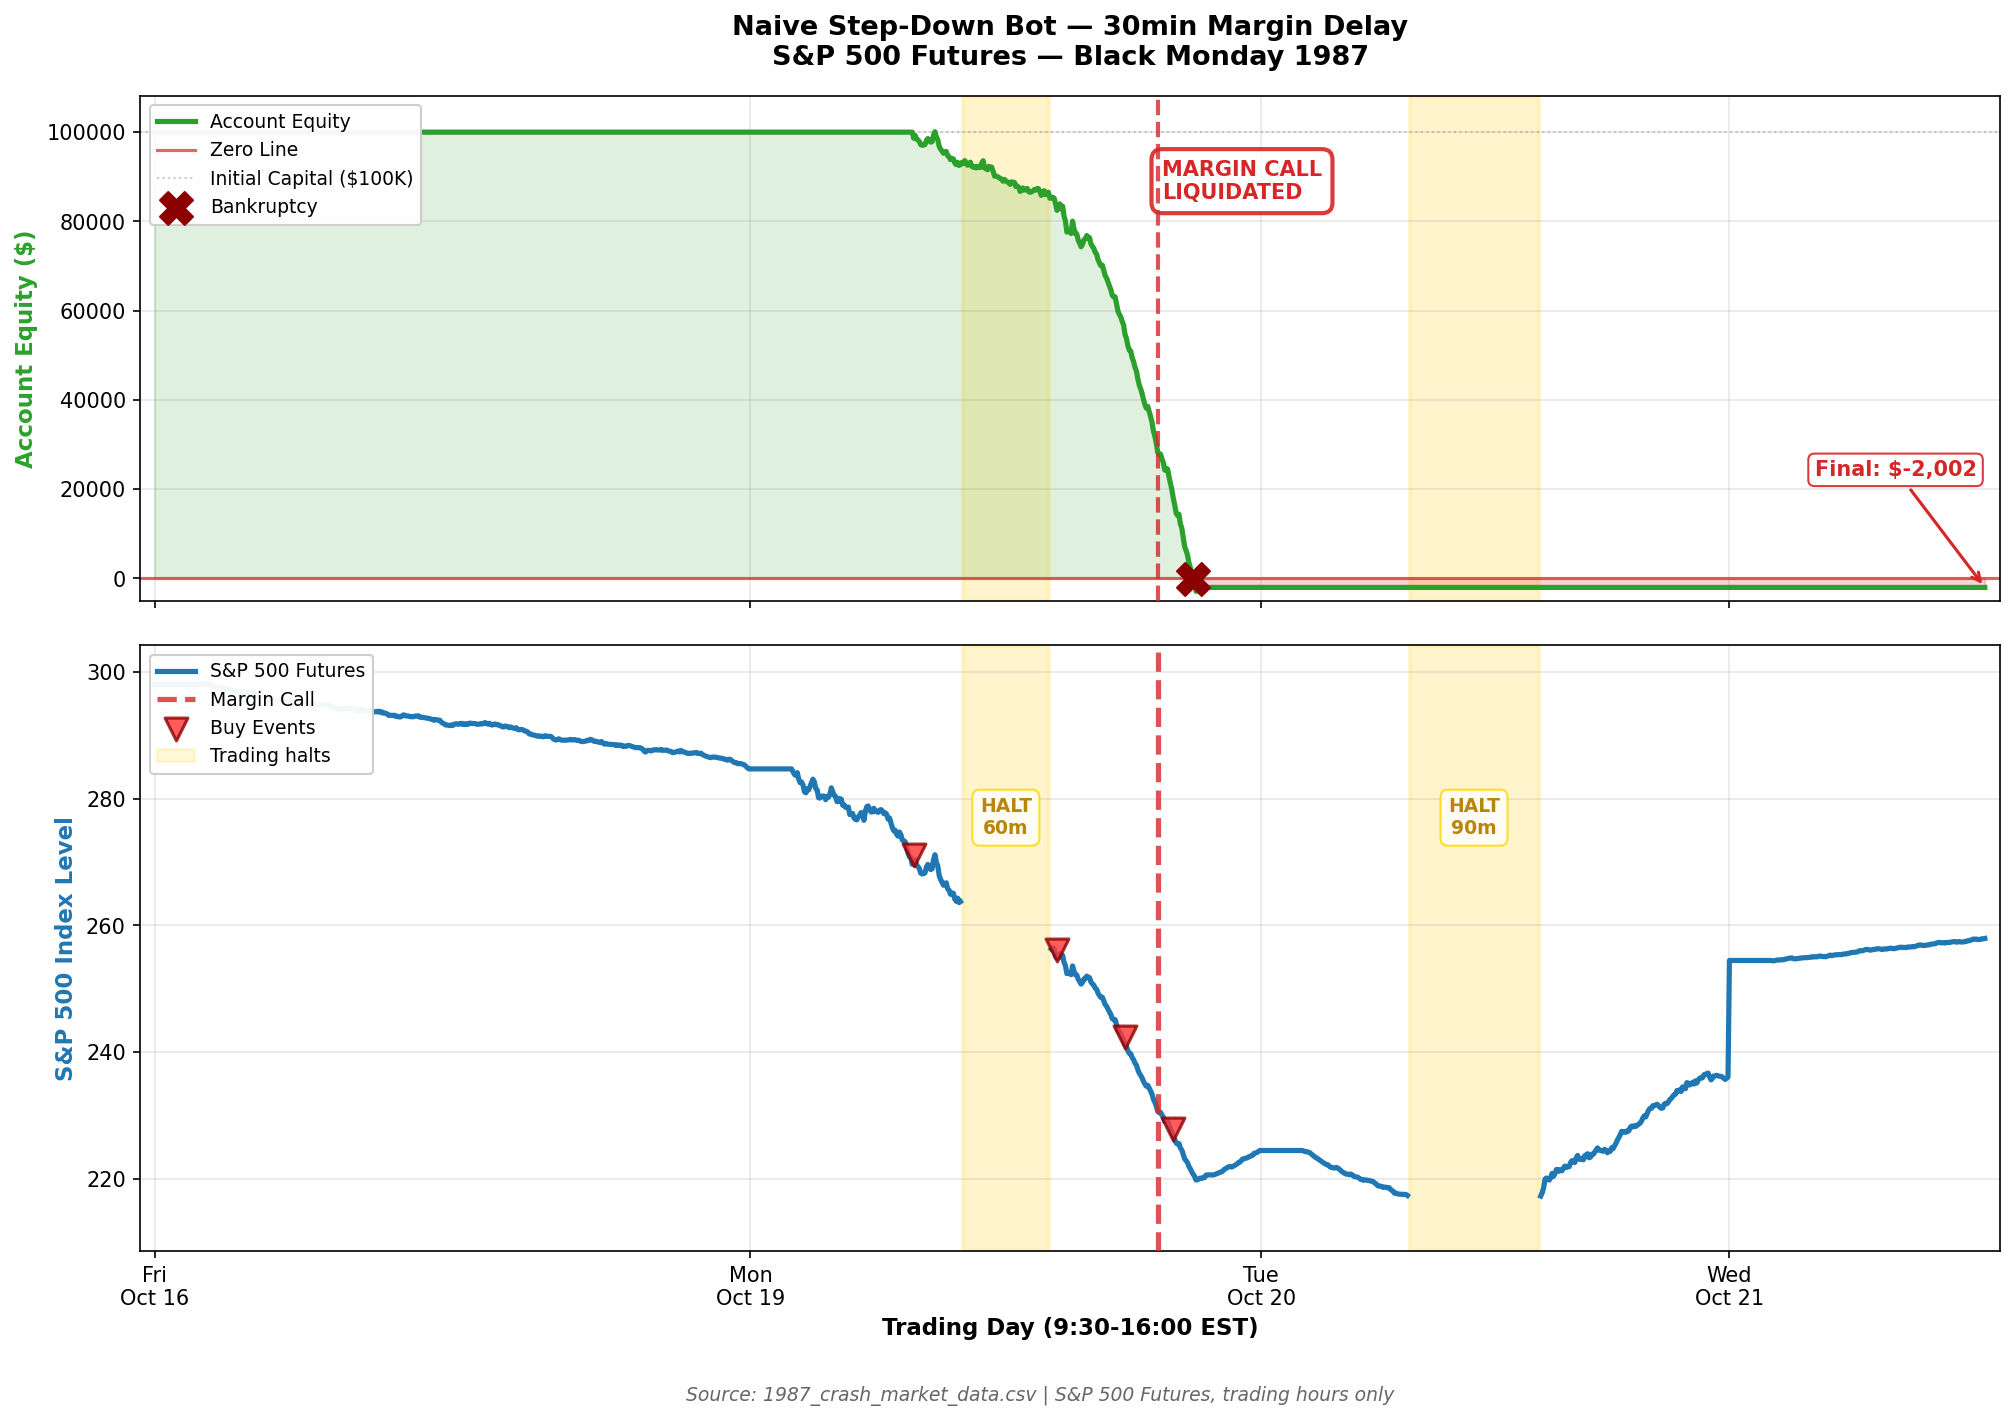

In [7]:
from IPython.display import Image, display
display(Image(chart_path))

### Scenario Comparison

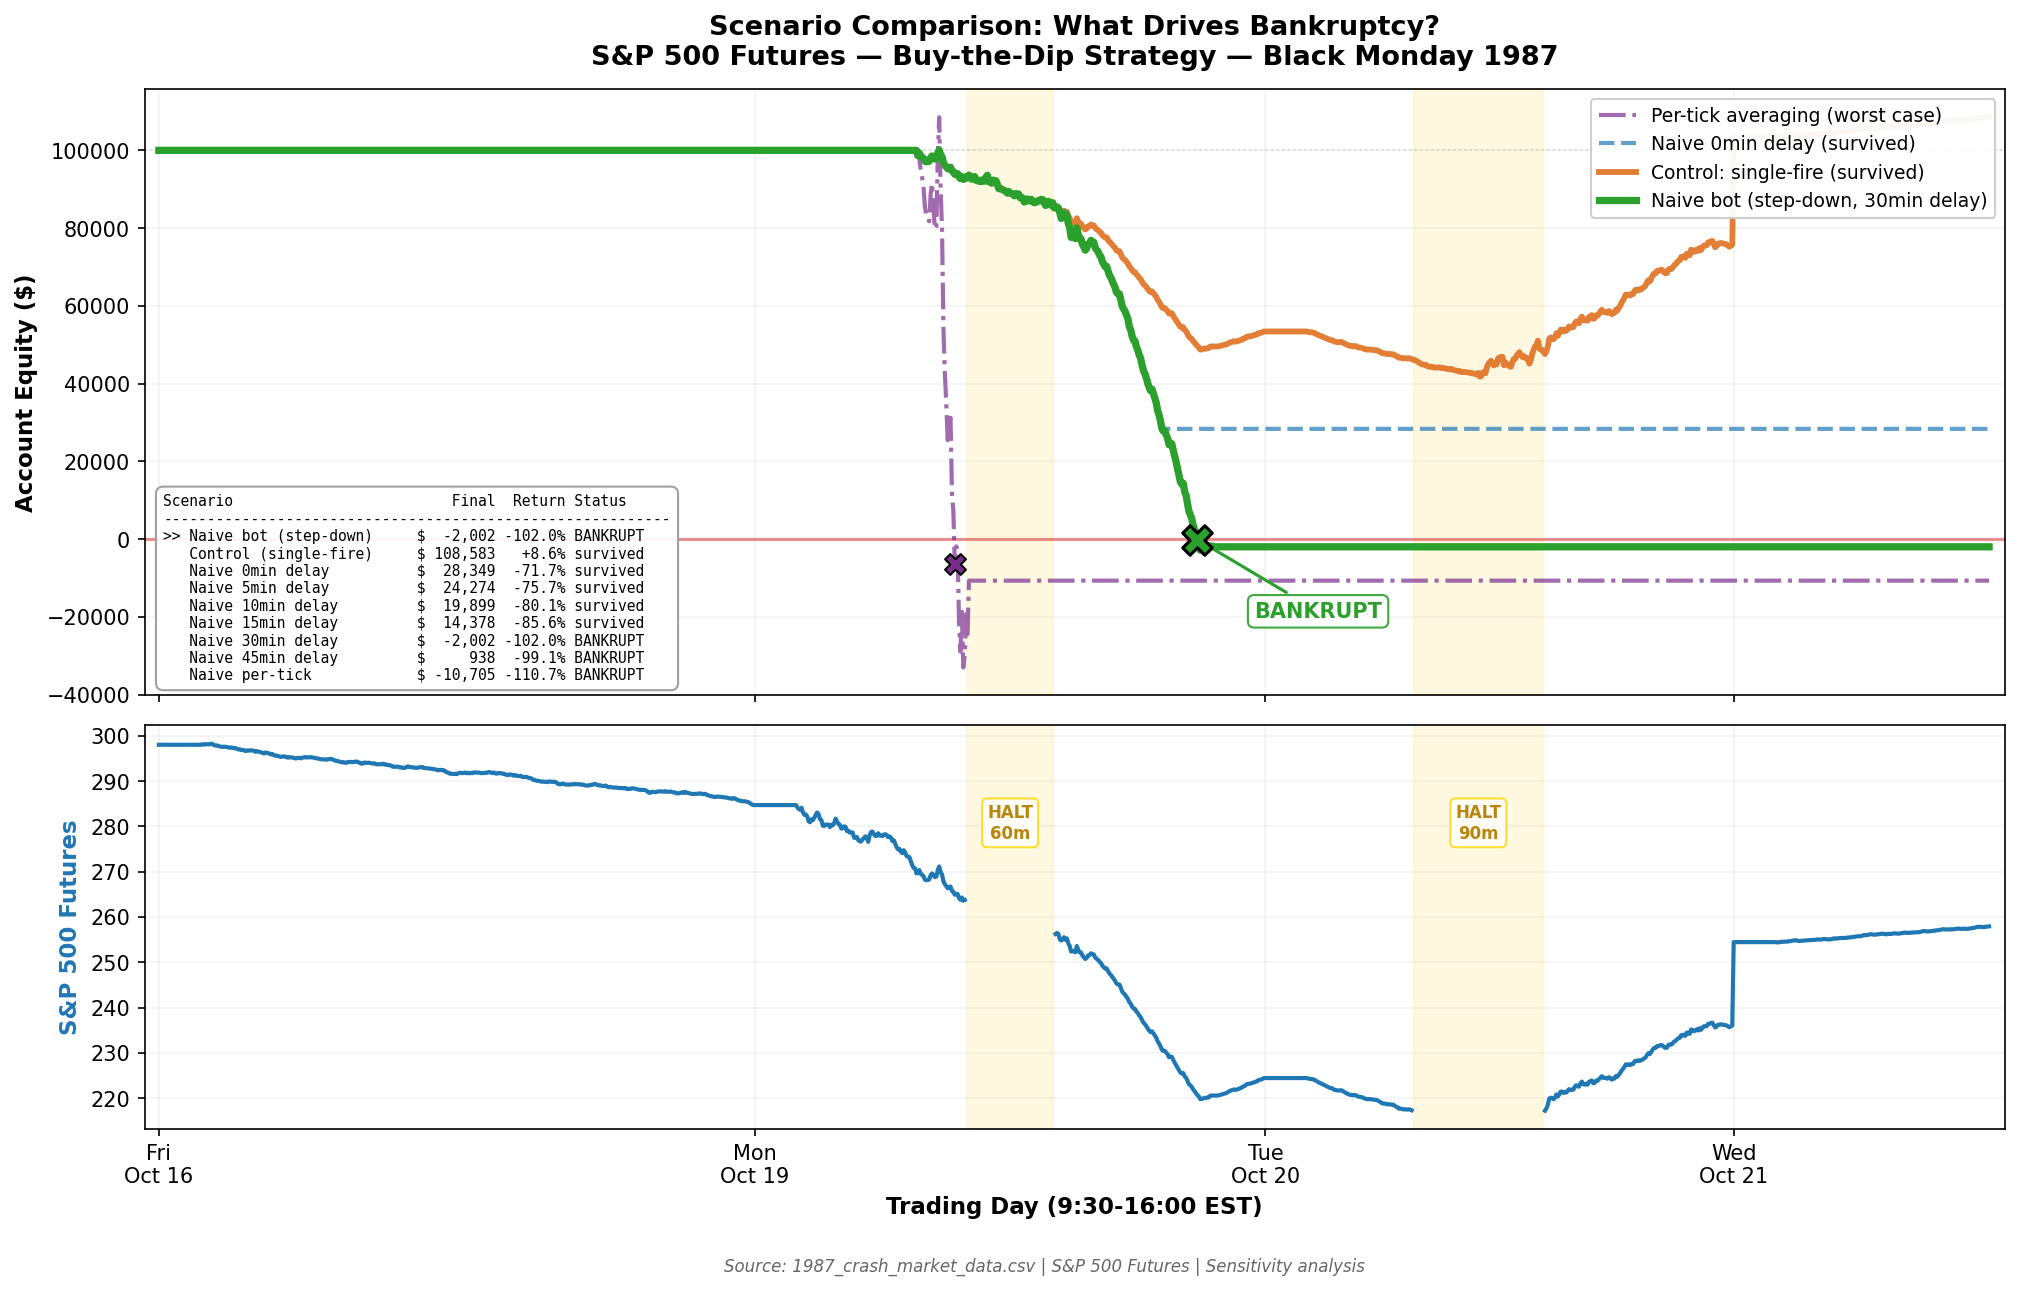

In [8]:
display(Image(comparison_path))

## 7. Results Summary Table

In [9]:
ic   = COMMON['initial_capital']
rows = []
for r in [primary, control] + delay_results + [per_tick]:
    fi  = r['final_value']
    ret = (fi - ic) / ic * 100
    lev = r['max_notional_exposure'] / ic
    rows.append({
        'Scenario':     r['scenario_name'],
        'Final Equity': f'${fi:,.0f}',
        'Return (%)':   f'{ret:+.1f}%',
        'Status':       fmt_status(r),
        'Max Leverage': f'{lev:.1f}x',
        'Buy Events':   len(r['buy_events']),
        'Margin Calls': r['margin_call_count'],
    })
pd.DataFrame(rows)

,Scenario,Final Equity,Return (%),Status,Max Leverage,Buy Events,Margin Calls
0,Naive bot (step-down),"$-2,002",-102.0%,BANKRUPT (equity <= $0),6.8x,4,1
1,Control (single-fire),"$108,583",+8.6%,survived,3.9x,2,0
2,Naive 0min delay,"$28,349",-71.7%,survived,6.0x,3,1
3,Naive 5min delay,"$24,274",-75.7%,survived,6.0x,3,1
4,Naive 10min delay,"$19,899",-80.1%,survived,6.0x,3,1
5,Naive 15min delay,"$14,378",-85.6%,survived,6.8x,4,1
6,Naive 30min delay,"$-2,002",-102.0%,BANKRUPT (equity <= $0),6.8x,4,1
7,Naive 45min delay,$938,-99.1%,"BANKRUPT (hit $0 intraday, settled $938)",6.8x,4,1
8,Naive per-tick,"$-10,705",-110.7%,BANKRUPT (equity <= $0),54.4x,25,1


## 8. Proposed Stop-Loss Rule

Based on the backtest results, a stop-loss is recommended to prevent bankruptcy under stressed market conditions.

In [10]:
print(f"Primary bot recommended stop-loss : {primary['stop_loss_pct']}% drawdown from peak")
print(f"Control bot recommended stop-loss : {control['stop_loss_pct']}% drawdown from peak")
print()
print('PROPOSED STOP-LOSS RULE:')
print('  Exit ALL positions if account equity falls more than 15% from its peak.')
print('  Under extreme stress (drawdown >= 90% or equity <= 0), use 20% trailing stop.')
print()
print('RATIONALE:')
print('  A 15% drawdown cap would have triggered an exit before the margin call')
print('  in the primary scenario, preventing formal bankruptcy.')
print('  The disciplined single-fire bot (control) never needed the stop-loss.')

Primary bot recommended stop-loss : 20.0% drawdown from peak
Control bot recommended stop-loss : 15.0% drawdown from peak

PROPOSED STOP-LOSS RULE:
  Exit ALL positions if account equity falls more than 15% from its peak.
  Under extreme stress (drawdown >= 90% or equity <= 0), use 20% trailing stop.

RATIONALE:
  A 15% drawdown cap would have triggered an exit before the margin call
  in the primary scenario, preventing formal bankruptcy.
  The disciplined single-fire bot (control) never needed the stop-loss.
